# Fruit & Veg — Seasonality EDA (2025)

**Scope:** Full calendar year 2025 · Department: FRUIT & VEG  
**Metrics:** Quantity sold · Sales (ex GST) · GP%  
**Grain:** Weekly (ISO week 1–52/53)

---

### Sections
1. Setup
2. Department-level weekly trend
3. Subdepartment weekly trend
4. Item-level seasonal variance
5. Key findings


## 1 · Setup

In [1]:
import sqlite3, pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
FIGSIZE_WIDE  = (16, 4)
FIGSIZE_TALL  = (16, 6)
FIGSIZE_HEAT  = (18, 7)

# ── DB connection (read-only) ──────────────────────────────────────────────────
DB_PATH = pathlib.Path('../foodland_data.db').resolve()
con = sqlite3.connect(f'file:{DB_PATH}?immutable=1', uri=True)

print(f'Connected → {DB_PATH}')

Connected → /sessions/hopeful-bold-curie/mnt/foodland_wudinna/foodland_data.db


In [2]:
# ── Load all 2025 F&V sales joined to dim_product ─────────────────────────────
SQL = """
SELECT
    fs.date_id,
    COALESCE(dp.sub_dept, 'Unknown')  AS sub_dept,
    dp.product_id,
    dp.name                           AS item,
    fs.quantity,
    fs.sales_ex_gst                   AS sales,
    fs.cost_ex_gst                    AS cost
FROM fact_sales fs
JOIN dim_product dp ON fs.product_id = dp.product_id
WHERE fs.date_id LIKE '2025%'
  AND fs.department = 'FRUIT & VEG'
  AND fs.sales_ex_gst > 0
ORDER BY fs.date_id
"""

raw = pd.read_sql(SQL, con, parse_dates=['date_id'])
raw['week']     = raw['date_id'].dt.isocalendar().week.astype(int)
raw['month']    = raw['date_id'].dt.month
raw['month_lbl']= raw['date_id'].dt.strftime('%b')
raw['gp']       = (raw['sales'] - raw['cost']) / raw['sales']   # item-day GP fraction

# Exclude open-ring / department-level rows (no PLU identity)
EXCLUDE_SUBDEPTS = {'Fruit & Vege Department Open', 'Unknown'}
clean = raw[~raw['sub_dept'].isin(EXCLUDE_SUBDEPTS)].copy()

print(f"Rows: {len(raw):,}  →  after excluding open-ring: {len(clean):,}")
print(f"Weeks covered: {raw['week'].min()} – {raw['week'].max()}")
print(f"Distinct items: {clean['item'].nunique()}")
print(f"Subdepts: {sorted(clean['sub_dept'].unique())}")

Rows: 31,802  →  after excluding open-ring: 30,890
Weeks covered: 1 – 52
Distinct items: 233
Subdepts: ['Fruit', 'Potatoes', 'Salads', 'Vegetables']


---
## 2 · Department-level weekly trend

Weekly aggregates across the whole Fruit & Veg department.

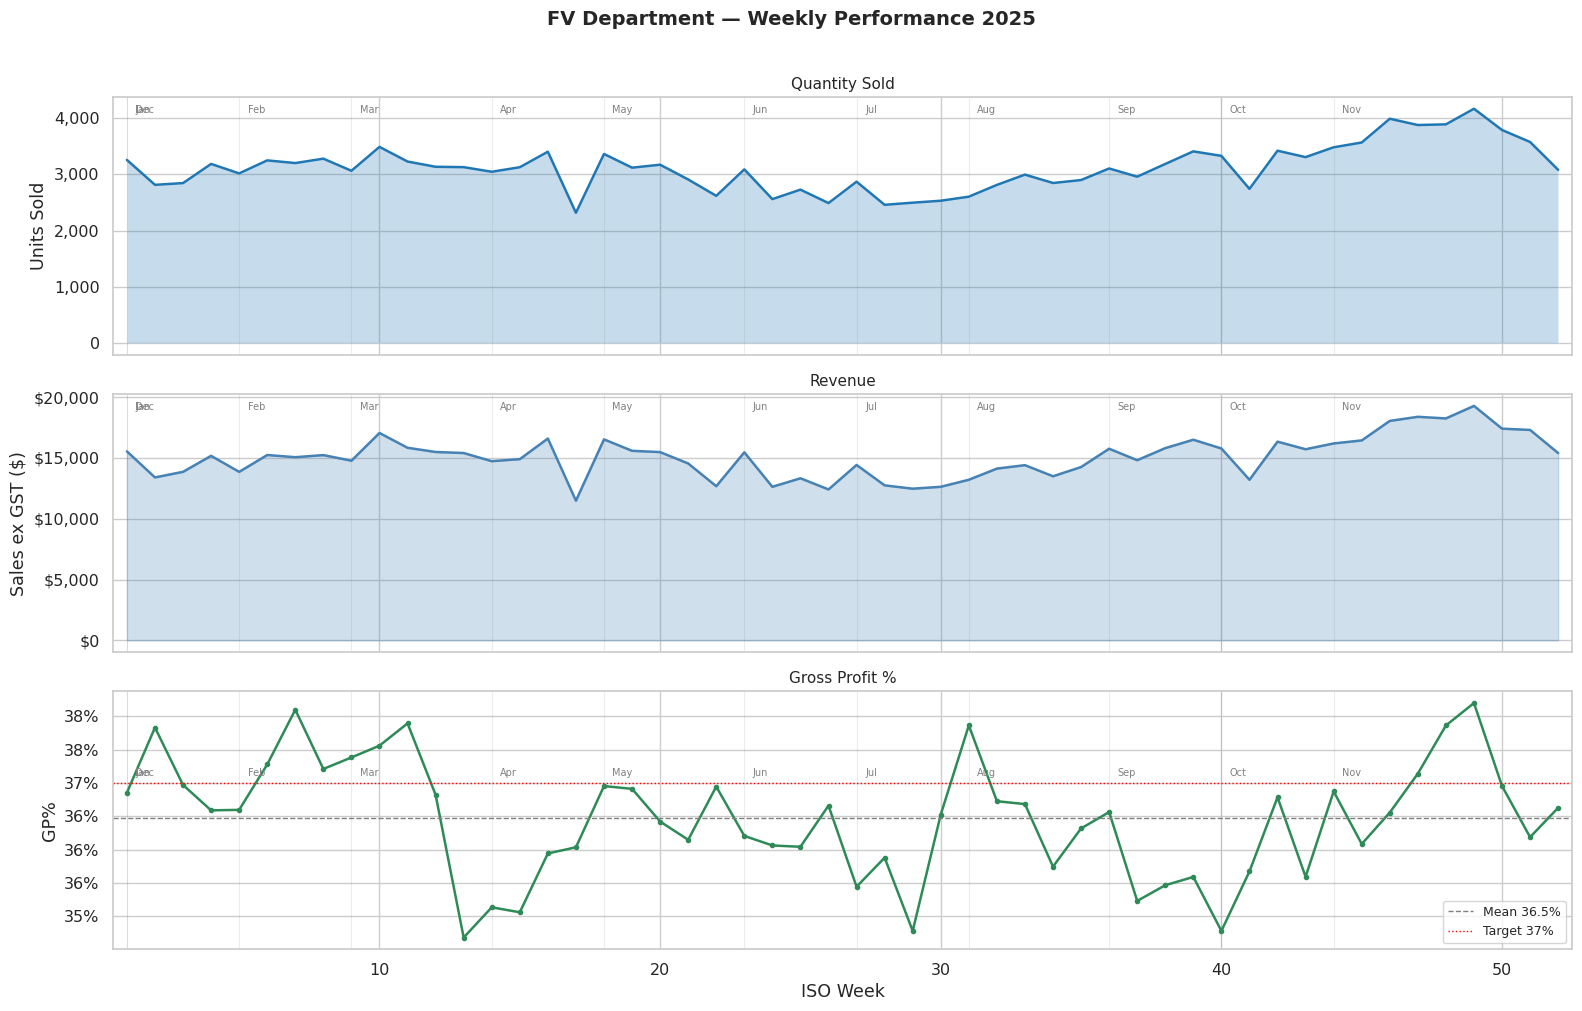


Metric                  Mean/wk        Min        Max      CoV
------------------------------------------------------------
Units                     3,118      2,317      4,164    13.1%
Sales $                  15,079     11,478     19,266    11.3%
GP%                        36.5       34.7       38.2     2.4%


In [3]:
# ── Weekly department aggregates ──────────────────────────────────────────────
dept_wk = (
    clean.groupby('week')
    .agg(qty=('quantity','sum'), sales=('sales','sum'), cost=('cost','sum'))
    .reset_index()
)
dept_wk['gp_pct'] = (dept_wk['sales'] - dept_wk['cost']) / dept_wk['sales'] * 100

# Month boundary annotations (first week each month appears)
month_weeks = (
    clean[['week','month','month_lbl']]
    .drop_duplicates()
    .sort_values('week')
    .groupby('month')
    .first()
    .reset_index()
)

def add_month_lines(ax, alpha=0.15):
    for _, row in month_weeks.iterrows():
        ax.axvline(row['week'], color='grey', lw=0.8, alpha=alpha)
        ax.text(row['week'] + 0.3, ax.get_ylim()[1]*0.97, row['month_lbl'],
                fontsize=7, color='grey', va='top')

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('FV Department — Weekly Performance 2025', fontsize=14, fontweight='bold', y=1.01)

# Qty
axes[0].fill_between(dept_wk['week'], dept_wk['qty'], alpha=0.25)
axes[0].plot(dept_wk['week'], dept_wk['qty'], lw=1.8)
axes[0].set_ylabel('Units Sold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].set_title('Quantity Sold', fontsize=11)
add_month_lines(axes[0])

# Sales
axes[1].fill_between(dept_wk['week'], dept_wk['sales'], alpha=0.25, color='steelblue')
axes[1].plot(dept_wk['week'], dept_wk['sales'], lw=1.8, color='steelblue')
axes[1].set_ylabel('Sales ex GST ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].set_title('Revenue', fontsize=11)
add_month_lines(axes[1])

# GP%
axes[2].plot(dept_wk['week'], dept_wk['gp_pct'], lw=1.8, color='seagreen', marker='o', ms=3)
axes[2].axhline(dept_wk['gp_pct'].mean(), ls='--', color='grey', lw=1, label=f'Mean {dept_wk["gp_pct"].mean():.1f}%')
axes[2].axhline(37.0, ls=':', color='red', lw=1, label='Target 37%')
axes[2].set_ylabel('GP%')
axes[2].set_xlabel('ISO Week')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
axes[2].set_title('Gross Profit %', fontsize=11)
axes[2].legend(fontsize=9)
add_month_lines(axes[2])

axes[2].set_xlim(dept_wk['week'].min()-0.5, dept_wk['week'].max()+0.5)

plt.tight_layout()
plt.show()

print(f"\n{'Metric':<18} {'Mean/wk':>12} {'Min':>10} {'Max':>10} {'CoV':>8}")
print('-'*60)
for col, label, fmt in [('qty','Units',',.0f'),('sales','Sales $',',.0f'),('gp_pct','GP%','.1f')]:
    s = dept_wk[col]
    cov = s.std()/s.mean()*100
    if fmt == '.1f':
        print(f"{label:<18} {s.mean():>12.1f} {s.min():>10.1f} {s.max():>10.1f} {cov:>7.1f}%")
    else:
        print(f"{label:<18} {s.mean():>12,.0f} {s.min():>10,.0f} {s.max():>10,.0f} {cov:>7.1f}%")

---
## 3 · Subdepartment weekly trend

Same view broken out by subdepartment: Fruit, Vegetables, Salads, Potatoes.

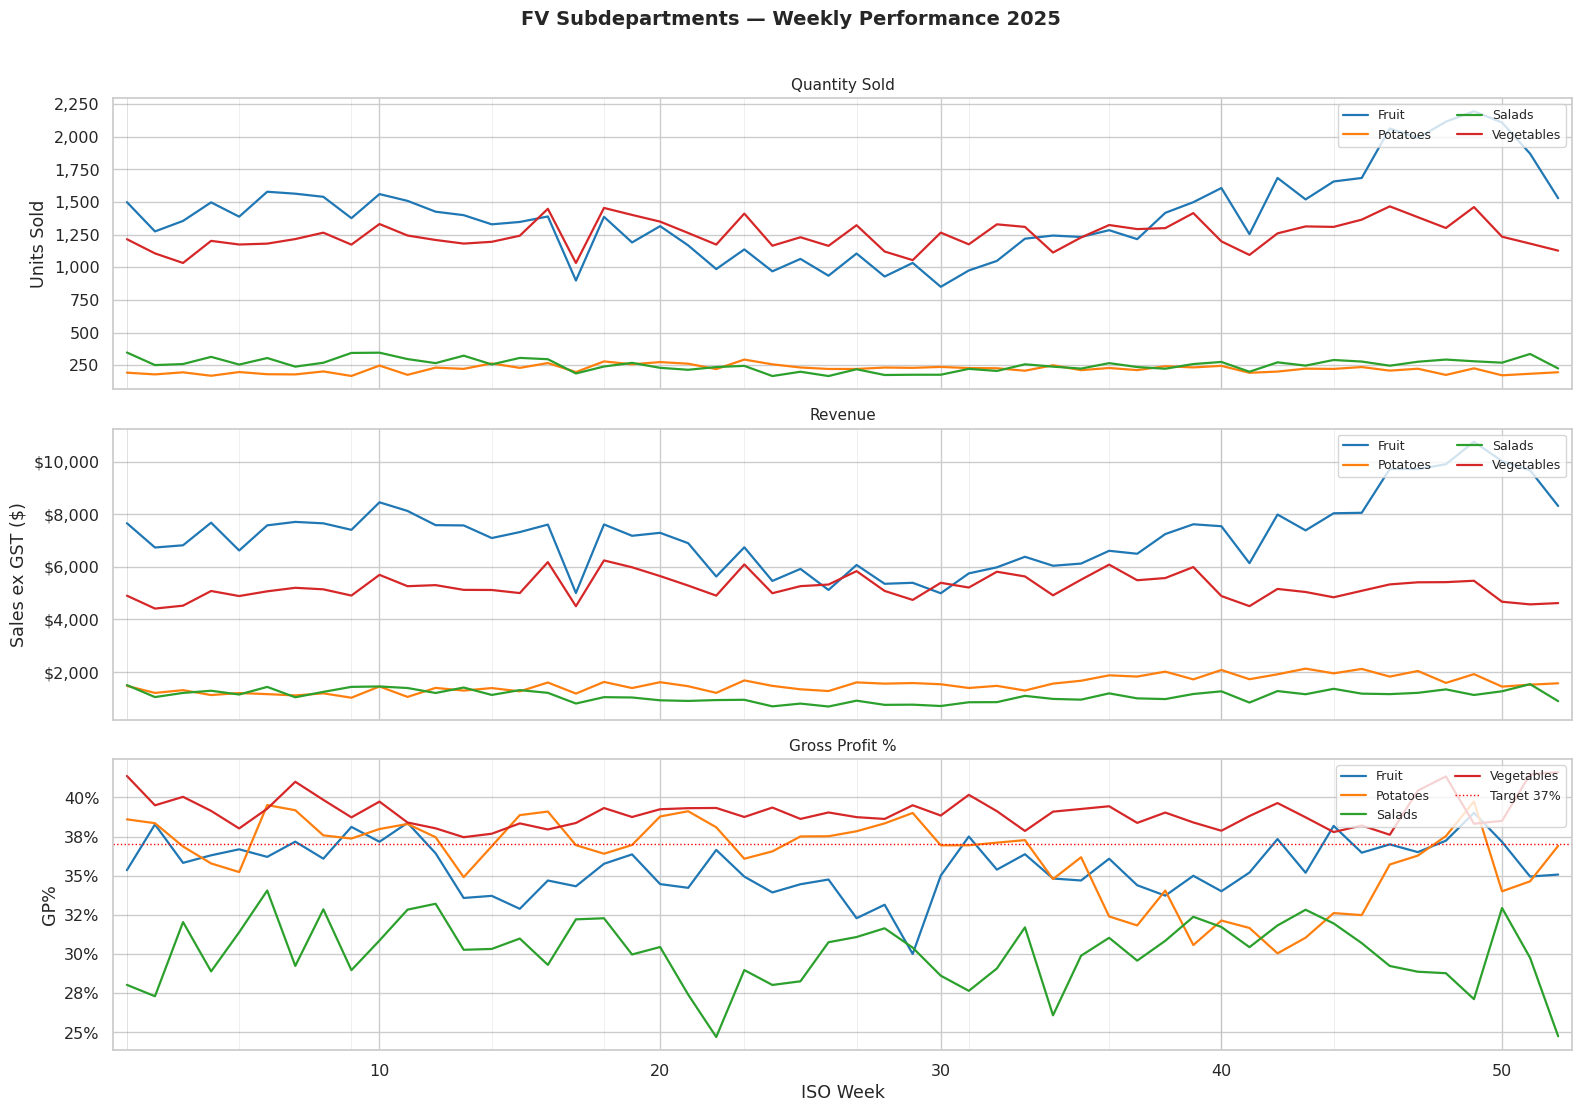

In [4]:
# ── Weekly by subdept ─────────────────────────────────────────────────────────
sub_wk = (
    clean.groupby(['week','sub_dept'])
    .agg(qty=('quantity','sum'), sales=('sales','sum'), cost=('cost','sum'))
    .reset_index()
)
sub_wk['gp_pct'] = (sub_wk['sales'] - sub_wk['cost']) / sub_wk['sales'] * 100

SUBDEPTS  = sorted(sub_wk['sub_dept'].unique())
PALETTE   = dict(zip(SUBDEPTS, sns.color_palette('tab10', len(SUBDEPTS))))

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle('FV Subdepartments — Weekly Performance 2025', fontsize=14, fontweight='bold', y=1.01)

for metric, ax, ylabel, title, fmt_fn in [
    ('qty',    axes[0], 'Units Sold',     'Quantity Sold', lambda x,_: f'{x:,.0f}'),
    ('sales',  axes[1], 'Sales ex GST ($)','Revenue',      lambda x,_: f'${x:,.0f}'),
    ('gp_pct', axes[2], 'GP%',            'Gross Profit %',lambda x,_: f'{x:.0f}%'),
]:
    for sd in SUBDEPTS:
        d = sub_wk[sub_wk['sub_dept']==sd].sort_values('week')
        ax.plot(d['week'], d[metric], lw=1.6, label=sd, color=PALETTE[sd])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_fn))
    if metric == 'gp_pct':
        ax.axhline(37, ls=':', color='red', lw=1, label='Target 37%')
        ax.set_xlabel('ISO Week')
    ax.legend(fontsize=9, loc='upper right', ncol=2)
    # light month lines
    for _, row in month_weeks.iterrows():
        ax.axvline(row['week'], color='grey', lw=0.6, alpha=0.15)

axes[0].set_xlim(sub_wk['week'].min()-0.5, sub_wk['week'].max()+0.5)
plt.tight_layout()
plt.show()

In [5]:
# ── Subdept summary table ──────────────────────────────────────────────────────
sub_summary = (
    clean.groupby('sub_dept')
    .agg(total_qty=('quantity','sum'), total_sales=('sales','sum'), total_cost=('cost','sum'))
    .assign(gp_pct=lambda d: (d.total_sales - d.total_cost)/d.total_sales*100,
            sales_share=lambda d: d.total_sales/d.total_sales.sum()*100)
    .sort_values('total_sales', ascending=False)
)

print(f"\n{'Subdept':<30} {'Total Qty':>12} {'Total Sales':>14} {'Sales Share':>12} {'GP%':>8}")
print('-'*80)
for sd, row in sub_summary.iterrows():
    print(f"{sd:<30} {row.total_qty:>12,.0f} ${row.total_sales:>13,.0f} {row.sales_share:>11.1f}% {row.gp_pct:>7.1f}%")


Subdept                           Total Qty    Total Sales  Sales Share      GP%
--------------------------------------------------------------------------------
Fruit                                72,438 $      375,790        47.9%    35.7%
Vegetables                           65,032 $      272,304        34.7%    39.1%
Potatoes                             11,462 $       79,239        10.1%    35.9%
Salads                               13,198 $       56,796         7.2%    30.2%


---
## 4 · Item-level seasonal variance

For each item we compute the **Coefficient of Variation (CoV)** of weekly quantity — i.e. how much its sales fluctuate relative to its own average. High CoV = highly seasonal.  
We focus on items with meaningful annual revenue (top 80% of sales) to avoid noise from minor SKUs.

In [6]:
# ── Weekly qty per item ────────────────────────────────────────────────────────
item_wk = (
    clean.groupby(['item','sub_dept','week'])
    .agg(qty=('quantity','sum'), sales=('sales','sum'), cost=('cost','sum'))
    .reset_index()
)

# Item annual totals & CoV across weeks
item_ann = (
    item_wk.groupby(['item','sub_dept'])
    .agg(
        total_qty   =('qty','sum'),
        total_sales =('sales','sum'),
        total_cost  =('cost','sum'),
        mean_wk_qty =('qty','mean'),
        std_wk_qty  =('qty','std'),
        weeks_sold  =('qty', lambda x: (x>0).sum())
    )
    .reset_index()
)
item_ann['gp_pct'] = (item_ann['total_sales'] - item_ann['total_cost']) / item_ann['total_sales'] * 100
item_ann['cov']    = item_ann['std_wk_qty'] / item_ann['mean_wk_qty'] * 100   # CoV in %

# Keep items covering ≥20 weeks (stable enough to measure seasonality)
item_ann = item_ann[item_ann['weeks_sold'] >= 20].copy()

# Revenue threshold: items in top 80% of cumulative sales
item_ann = item_ann.sort_values('total_sales', ascending=False)
item_ann['cum_share'] = item_ann['total_sales'].cumsum() / item_ann['total_sales'].sum()
item_main = item_ann[item_ann['cum_share'] <= 0.80].copy()

print(f"Items analysed (≥20 weeks): {len(item_ann)}")
print(f"Items in top-80% revenue: {len(item_main)}")
print(f"\nTop 10 most seasonal items (highest CoV, top-80% revenue):")
top_seasonal = item_main.nlargest(10, 'cov')[['item','sub_dept','total_sales','mean_wk_qty','cov','gp_pct','weeks_sold']]
top_seasonal.columns = ['Item','SubDept','Annual Sales','Mean Wk Qty','CoV %','GP%','Weeks Sold']
print(top_seasonal.to_string(index=False, float_format=lambda x: f'{x:.1f}'))

Items analysed (≥20 weeks): 147
Items in top-80% revenue: 53

Top 10 most seasonal items (highest CoV, top-80% revenue):
                                Item SubDept  Annual Sales  Mean Wk Qty  CoV %  GP%  Weeks Sold
                   NECTARINES YELLOW   Fruit        4554.2         22.8   98.1 36.0          25
                    MANGOES PER EACH   Fruit        8655.7         81.6   95.0 33.4          30
          WATERMELON SEEDLESS PER KG   Fruit       21924.6        141.8   65.6 39.8          52
TOMATOES - CHERRY SAMPARI TRUSS 250G   Fruit        5299.3         19.7   64.8 37.1          52
        GRAPES BLACK SEEDLESS PER KG   Fruit        4084.4         21.3   62.3 35.0          26
                 GRAPES GREEN PER KG   Fruit       15880.6         53.6   61.2 33.0          37
                  GRAPES DARK PER KG   Fruit        9370.3         34.7   58.6 35.7          40
       TOMATOES - CHERRY PUNNET 250G   Fruit        6844.8         34.0   54.6 36.9          52
               

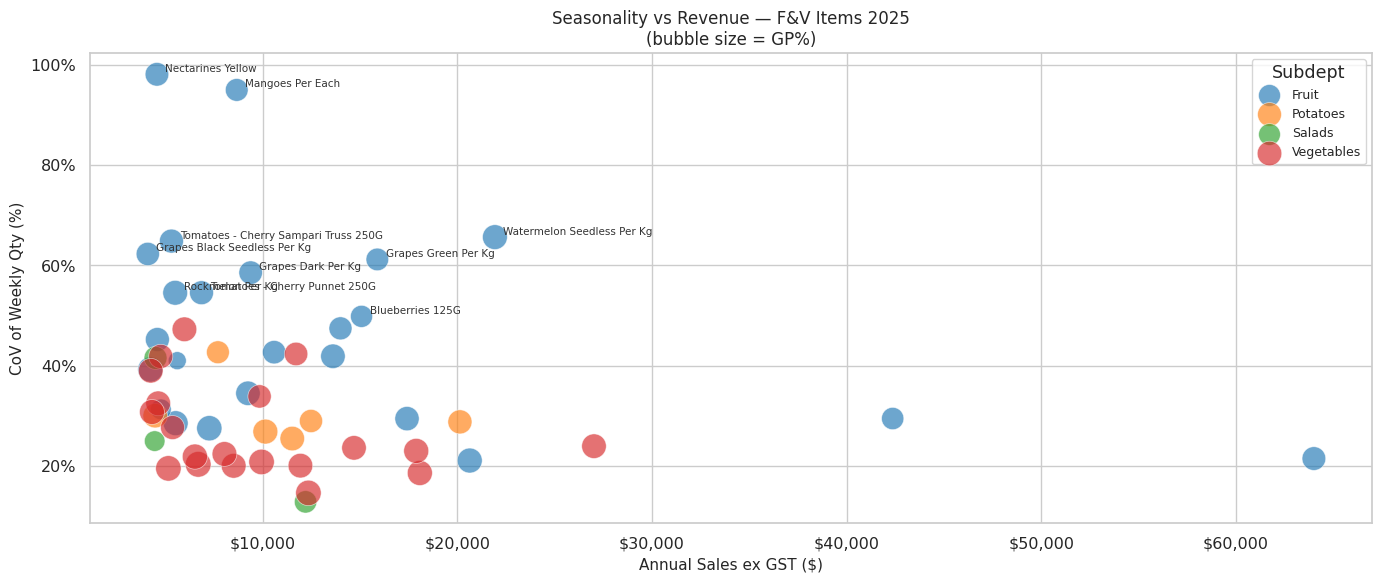

In [7]:
# ── Chart: CoV vs Annual Sales (bubble = GP%) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for sd in SUBDEPTS:
    d = item_main[item_main['sub_dept']==sd]
    sc = ax.scatter(
        d['total_sales'], d['cov'],
        s = d['gp_pct'] * 8,          # bubble size ∝ GP%
        color=PALETTE.get(sd,'grey'),
        alpha=0.65, label=sd, edgecolors='white', lw=0.5
    )

# Label top-10 seasonal items
for _, row in item_main.nlargest(10, 'cov').iterrows():
    ax.annotate(
        row['item'].title(), (row['total_sales'], row['cov']),
        xytext=(6, 2), textcoords='offset points', fontsize=7.5, color='#333'
    )

ax.set_xlabel('Annual Sales ex GST ($)', fontsize=11)
ax.set_ylabel('CoV of Weekly Qty (%)', fontsize=11)
ax.set_title('Seasonality vs Revenue — F&V Items 2025\n(bubble size = GP%)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.legend(title='Subdept', fontsize=9)
plt.tight_layout()
plt.show()

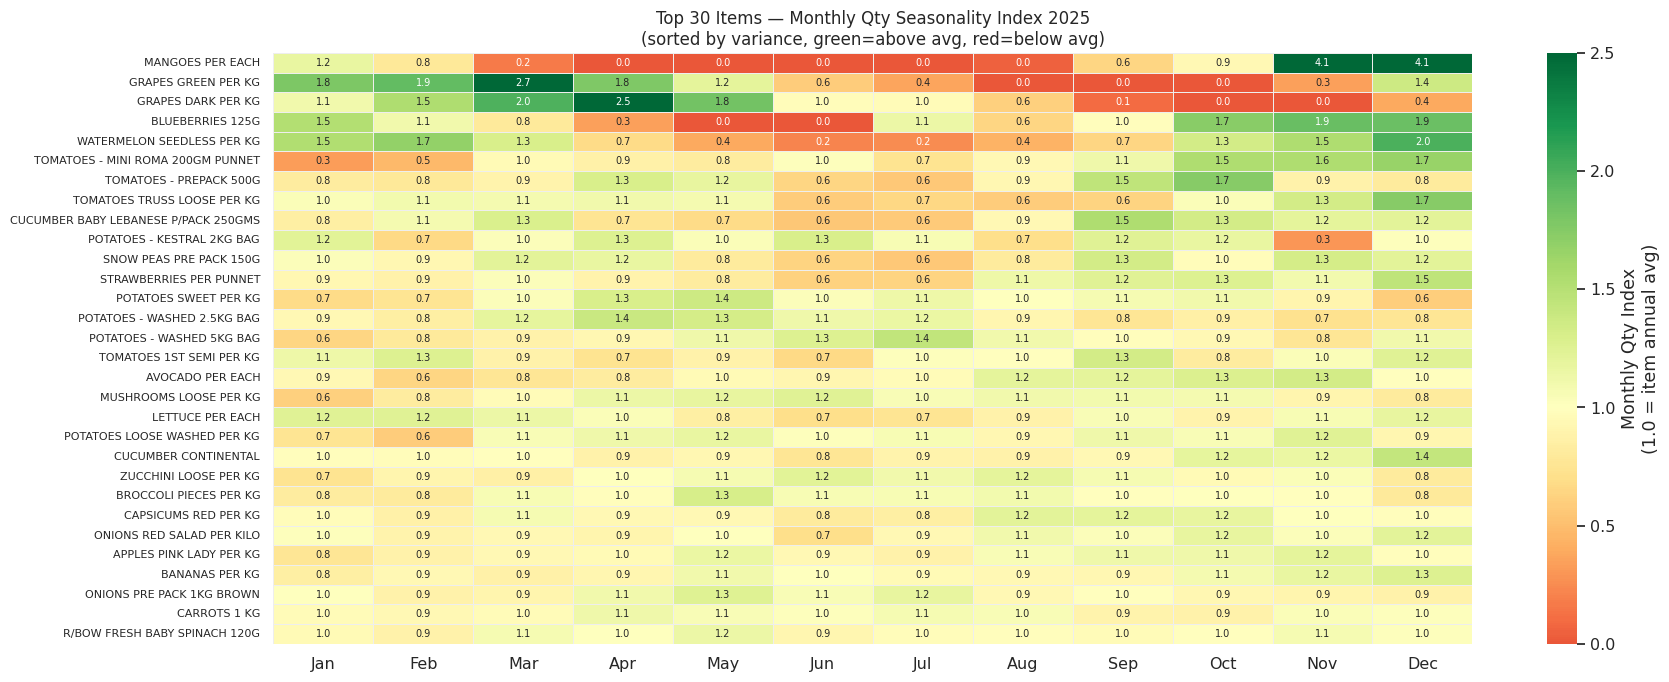

In [8]:
# ── Heatmap: Top 30 items × Month (qty index vs item annual average) ───────────
# Normalise to 1.0 = item's annual monthly average, so high months stand out

top30 = item_main.nlargest(30, 'total_sales')['item'].tolist()

item_mo = (
    clean[clean['item'].isin(top30)]
    .groupby(['item','month'])[['quantity']]
    .sum()
    .reset_index()
)
pivot = item_mo.pivot(index='item', columns='month', values='quantity').fillna(0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Normalise each row by its row mean
pivot_norm = pivot.div(pivot.mean(axis=1), axis=0)

# Sort rows by CoV of normalised row (most seasonal first)
pivot_norm = pivot_norm.loc[pivot_norm.std(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=FIGSIZE_HEAT)
sns.heatmap(
    pivot_norm,
    cmap='RdYlGn', center=1.0, vmin=0.0, vmax=2.5,
    linewidths=0.4, linecolor='#eee',
    annot=pivot_norm.round(1), fmt='.1f', annot_kws={'size':7},
    cbar_kws={'label':'Monthly Qty Index\n(1.0 = item annual avg)'},
    ax=ax
)
ax.set_title('Top 30 Items — Monthly Qty Seasonality Index 2025\n(sorted by variance, green=above avg, red=below avg)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

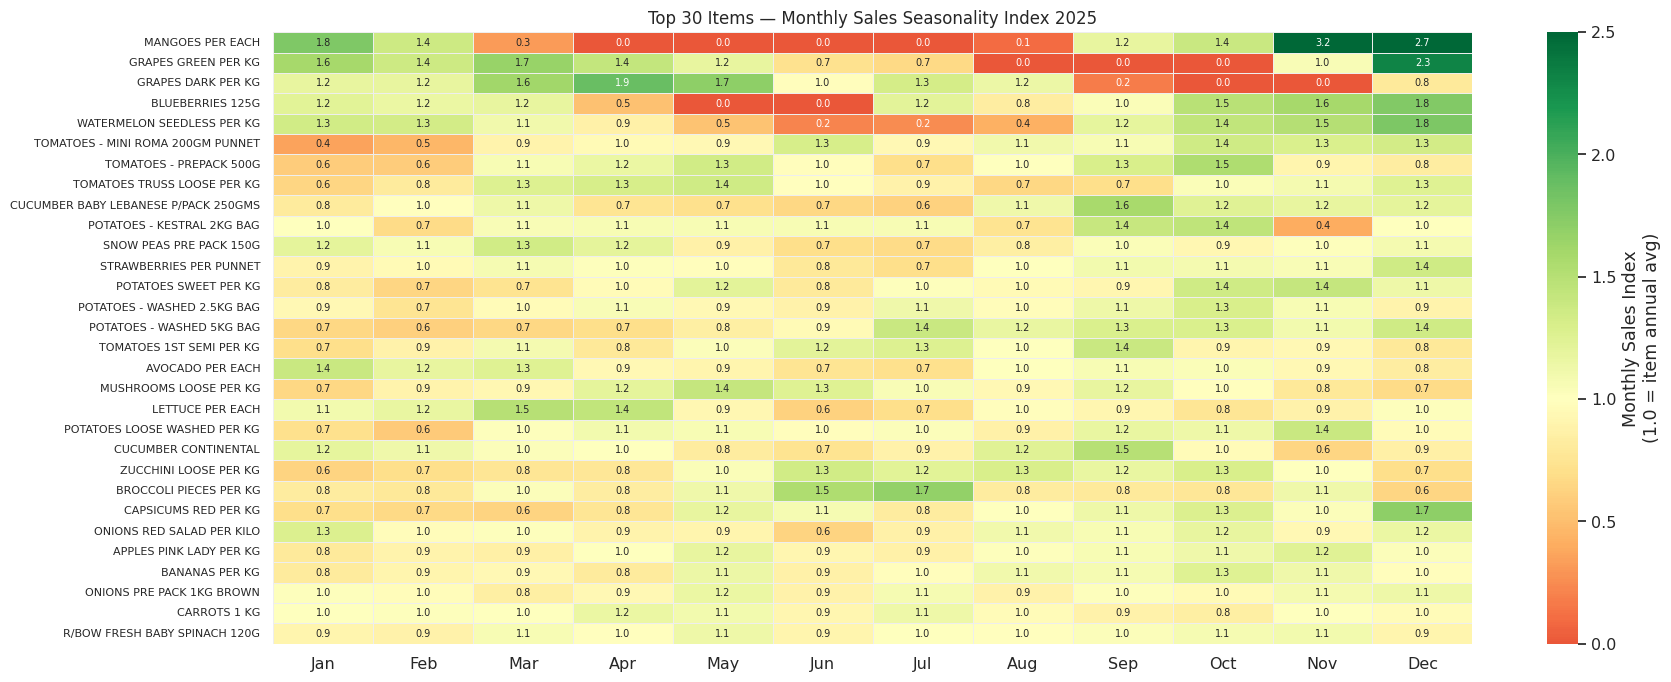

In [9]:
# ── Sales heatmap: same top-30 but in $-index ─────────────────────────────────
item_mo_sales = (
    clean[clean['item'].isin(top30)]
    .groupby(['item','month'])[['sales']]
    .sum()
    .reset_index()
)
pivot_s = item_mo_sales.pivot(index='item', columns='month', values='sales').fillna(0)
pivot_s.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot_s_norm = pivot_s.div(pivot_s.mean(axis=1), axis=0)
# Keep same row order as qty heatmap for easy comparison
pivot_s_norm = pivot_s_norm.reindex(pivot_norm.index)

fig, ax = plt.subplots(figsize=FIGSIZE_HEAT)
sns.heatmap(
    pivot_s_norm,
    cmap='RdYlGn', center=1.0, vmin=0.0, vmax=2.5,
    linewidths=0.4, linecolor='#eee',
    annot=pivot_s_norm.round(1), fmt='.1f', annot_kws={'size':7},
    cbar_kws={'label':'Monthly Sales Index\n(1.0 = item annual avg)'},
    ax=ax
)
ax.set_title('Top 30 Items — Monthly Sales Seasonality Index 2025', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

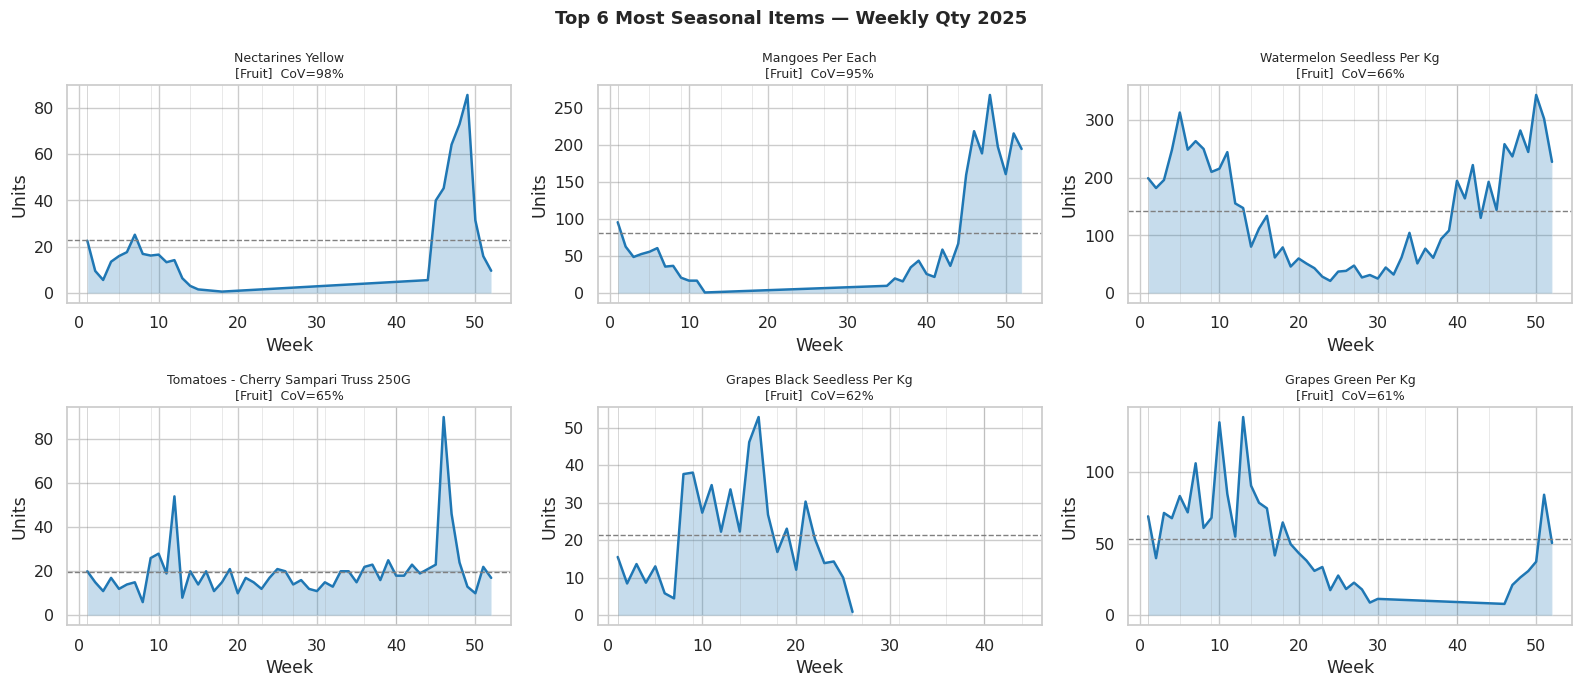

In [10]:
# ── Detail lines: top-6 most seasonal items ───────────────────────────────────
top6_seasonal = item_main.nlargest(6, 'cov')['item'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharey=False)
fig.suptitle('Top 6 Most Seasonal Items — Weekly Qty 2025', fontsize=13, fontweight='bold')

for ax, item in zip(axes.flat, top6_seasonal):
    d = item_wk[item_wk['item']==item].sort_values('week')
    ax.fill_between(d['week'], d['qty'], alpha=0.25)
    ax.plot(d['week'], d['qty'], lw=1.8)
    ax.axhline(d['qty'].mean(), ls='--', color='grey', lw=1)
    subdept = item_main.loc[item_main['item']==item,'sub_dept'].values[0]
    cov_val = item_main.loc[item_main['item']==item,'cov'].values[0]
    ax.set_title(f'{item.title()}\n[{subdept}]  CoV={cov_val:.0f}%', fontsize=9)
    ax.set_xlabel('Week')
    ax.set_ylabel('Units')
    # light month markers
    for _, row in month_weeks.iterrows():
        ax.axvline(row['week'], color='grey', lw=0.6, alpha=0.2)

plt.tight_layout()
plt.show()

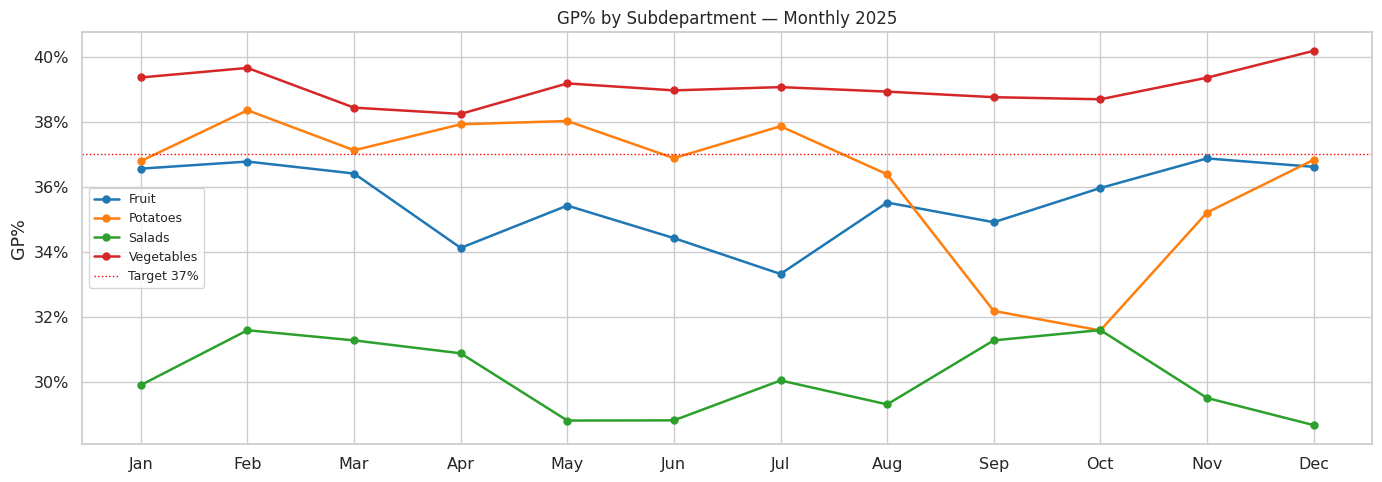

In [11]:
# ── GP% seasonality by subdept (monthly) ──────────────────────────────────────
gp_mo = (
    clean.groupby(['sub_dept','month'])
    .agg(sales=('sales','sum'), cost=('cost','sum'))
    .reset_index()
)
gp_mo['gp_pct'] = (gp_mo['sales'] - gp_mo['cost']) / gp_mo['sales'] * 100
gp_mo['month_lbl'] = gp_mo['month'].apply(lambda m: ['Jan','Feb','Mar','Apr','May','Jun',
                                                       'Jul','Aug','Sep','Oct','Nov','Dec'][m-1])

fig, ax = plt.subplots(figsize=(14, 5))
for sd in SUBDEPTS:
    d = gp_mo[gp_mo['sub_dept']==sd].sort_values('month')
    ax.plot(d['month'], d['gp_pct'], lw=1.8, marker='o', ms=5, label=sd, color=PALETTE.get(sd,'grey'))

ax.axhline(37, ls=':', color='red', lw=1, label='Target 37%')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('GP%')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.set_title('GP% by Subdepartment — Monthly 2025', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 5 · Key Findings

> Summary written after running the analysis. Update numbers if data changes.

In [12]:
# ── Auto-generate a summary of the key numbers ────────────────────────────────
total_sales   = clean['sales'].sum()
total_qty     = clean['quantity'].sum()
total_gp      = (clean['sales'].sum() - clean['cost'].sum()) / clean['sales'].sum() * 100
peak_wk       = dept_wk.loc[dept_wk['sales'].idxmax()]
trough_wk     = dept_wk.loc[dept_wk['sales'].idxmin()]
peak_ratio    = peak_wk['sales'] / trough_wk['sales']

most_seasonal_item  = item_main.nlargest(1,'cov').iloc[0]
least_seasonal_item = item_main.nsmallest(1,'cov').iloc[0]

gp_by_month = (
    clean.groupby('month')
    .agg(s=('sales','sum'), c=('cost','sum'))
    .eval('gp=(s-c)/s*100')
)
best_gp_month  = gp_by_month['gp'].idxmax()
worst_gp_month = gp_by_month['gp'].idxmin()
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print('='*70)
print('  FRUIT & VEG — SEASONALITY EDA  |  YEAR 2025  |  SUMMARY')
print('='*70)
print(f'\n  Annual revenue (ex GST): ${total_sales:,.0f}')
print(f'  Annual quantity sold:    {total_qty:,.0f} units')
print(f'  Full-year GP%:           {total_gp:.1f}%')
print()
print(f'  Peak week (W{int(peak_wk["week"]):02d}):   ${peak_wk["sales"]:,.0f}/wk  '
      f'({peak_wk["qty"]:,.0f} units)')
print(f'  Trough week (W{int(trough_wk["week"]):02d}): ${trough_wk["sales"]:,.0f}/wk  '
      f'({trough_wk["qty"]:,.0f} units)')
print(f'  Peak/trough ratio:       {peak_ratio:.1f}x')
print()
print(f'  Most seasonal item:      {most_seasonal_item["item"]} '
      f'(CoV {most_seasonal_item["cov"]:.0f}%)')
print(f'  Least seasonal item:     {least_seasonal_item["item"]} '
      f'(CoV {least_seasonal_item["cov"]:.0f}%)')
print()
print(f'  Best GP% month:          {MONTH_NAMES[best_gp_month-1]}  ({gp_by_month.loc[best_gp_month,"gp"]:.1f}%)')
print(f'  Worst GP% month:         {MONTH_NAMES[worst_gp_month-1]}  ({gp_by_month.loc[worst_gp_month,"gp"]:.1f}%)')
print()
print('  Subdept breakdown (annual sales share):')
for sd, row in sub_summary.iterrows():
    print(f'    {sd:<30} {row.sales_share:>5.1f}%  GP {row.gp_pct:.1f}%')
print('='*70)

  FRUIT & VEG — SEASONALITY EDA  |  YEAR 2025  |  SUMMARY

  Annual revenue (ex GST): $784,129
  Annual quantity sold:    162,129 units
  Full-year GP%:           36.5%

  Peak week (W49):   $19,266/wk  (4,164 units)
  Trough week (W17): $11,478/wk  (2,317 units)
  Peak/trough ratio:       1.7x

  Most seasonal item:      NECTARINES YELLOW (CoV 98%)
  Least seasonal item:     R/BOW FRESH BABY SPINACH 120G (CoV 13%)

  Best GP% month:          Feb  (37.4%)
  Worst GP% month:         Apr  (35.7%)

  Subdept breakdown (annual sales share):
    Fruit                           47.9%  GP 35.7%
    Vegetables                      34.7%  GP 39.1%
    Potatoes                        10.1%  GP 35.9%
    Salads                           7.2%  GP 30.2%
